In [9]:
import pandas_datareader as pdr
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# Generate dummy time series data
date = pd.date_range(start='2020-01-01', periods=100, freq='M')
values = np.random.randn(100)

data = pd.DataFrame({'Date': date, 'Value': values})
data.set_index('Date', inplace=True)

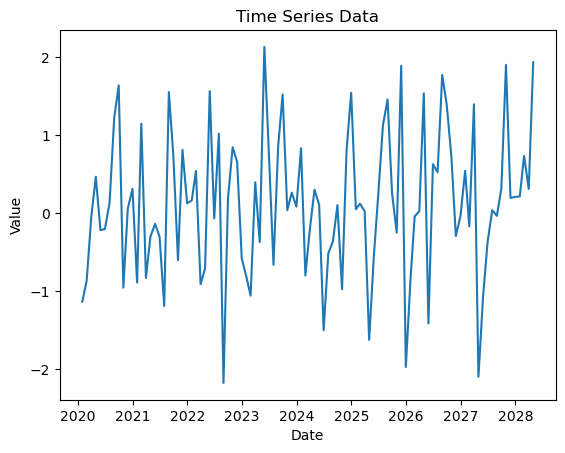

In [13]:
plt.plot(data.index,data['Value'])
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Time Series Data')
plt.show()

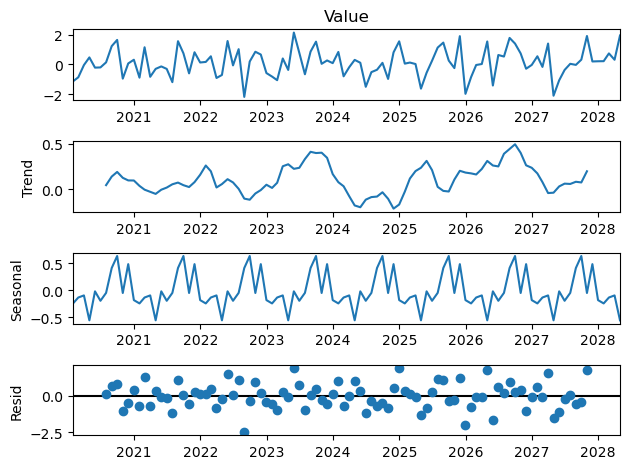

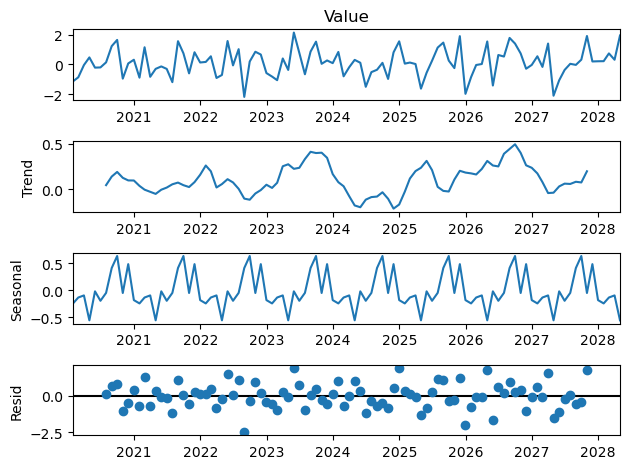

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data['Value'], model='additive')
result.plot()

In [15]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(data['Value'])
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")    

The time series is stationary.


c:\Users\sm\AppData\Local\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


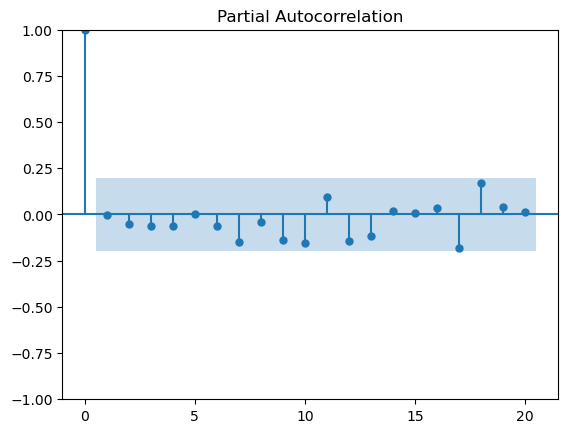

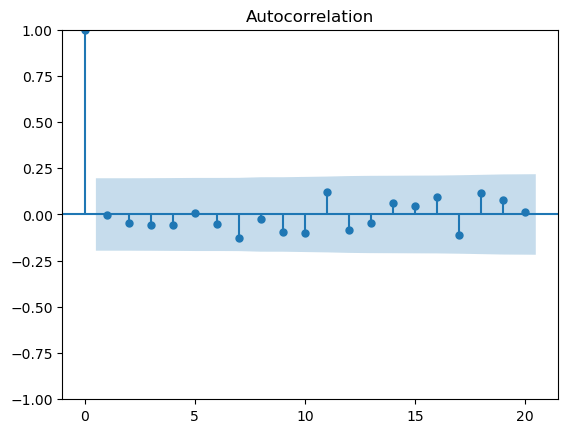

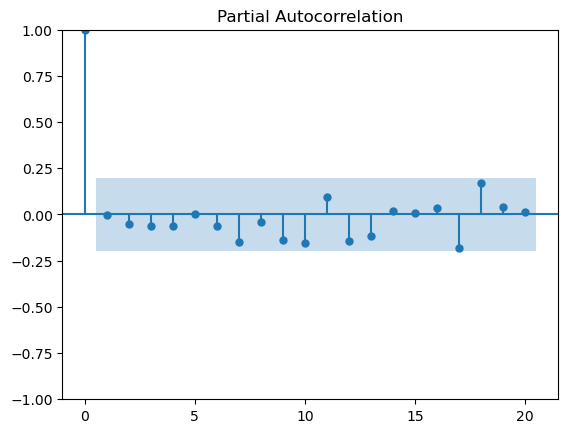

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(data['Value'])
plot_pacf(data['Value'])

In [20]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['Value'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

c:\Users\sm\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
c:\Users\sm\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
c:\Users\sm\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -135.961
Date:                Sun, 03 May 2026   AIC                            277.921
Time:                        17:04:35   BIC                            285.707
Sample:                    01-31-2020   HQIC                           281.071
                         - 04-30-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0066      0.113      0.059      0.953      -0.214       0.227
ma.L1         -0.9995      1.994     -0.501      0.616      -4.908       2.909
sigma2         0.8717      1.725      0.505      0.6

Forecast Values:
2028-05-31    0.138426
2028-06-30    0.126504
2028-07-31    0.126425
2028-08-31    0.126425
2028-09-30    0.126425
2028-10-31    0.126425
2028-11-30    0.126425
2028-12-31    0.126425
2029-01-31    0.126425
2029-02-28    0.126425
Freq: M, Name: predicted_mean, dtype: float64


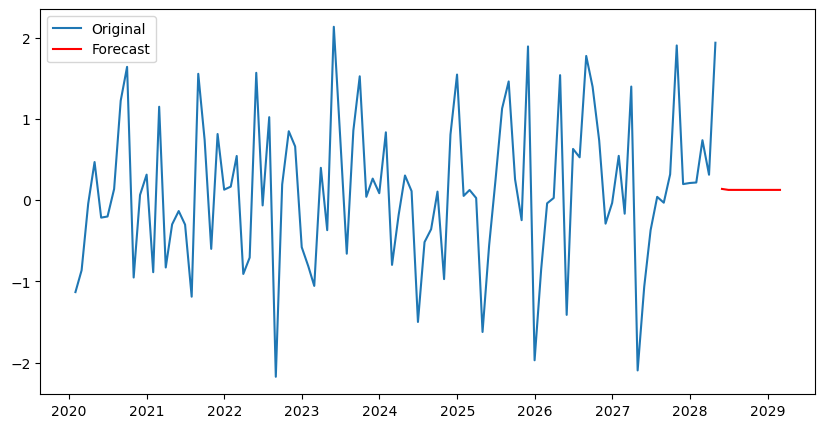

In [21]:
forecast = model_fit.forecast(steps=10)

print("Forecast Values:")
print(forecast)

# Plot forecast
plt.figure(figsize=(10,5))
plt.plot(data, label='Original')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()
